In [2]:
import tensorflow as tf
print(tf.__version__)

2.13.0


In [4]:
import datetime
import numpy as np
import pandas as pd
from scipy.io import loadmat
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn import metrics
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import random as rnd

# Data Preprocessing


Data preprocessing to divide the data into sequences of 10 observations in each cycle, the sequence have overlap with eachother.

In [5]:
def generate_sequences(data, window_size):
    X, y_capacity, y_RUL, y_SOH = [], [], [], []
    cyclic_RUL_x, cyclic_RUL_y = [], []

    cycles = data['cycle'].unique()
    initial_capacity = data.iloc[0]['capacity']

    # Normalize all 'capacity' values by the first row's 'capacity' value
    data['SOH'] = data['capacity'] / initial_capacity

    # dividing the data of each cycle into sequences
    for cycle in cycles:
        cycle_data = data[data['cycle'] == cycle]
        cycle_observations = []
        num_rows = len(cycle_data)

        if num_rows >= window_size:
            for start in range(num_rows - window_size + 1):
                end = start + window_size

                features = cycle_data.iloc[start:end].drop(['cycle', 'capacity', 'RUL', 'SOH'], axis=1).values # Exclude 'cycle', 'capacity', 'RUL', 'SOH'
                target_capacity = cycle_data.iloc[end-1, cycle_data.columns.get_loc('capacity')] # Capacity target
                target_SOH = cycle_data.iloc[end-1, cycle_data.columns.get_loc('SOH')] # SOH target
                target_RUL = cycle_data.iloc[end-1, cycle_data.columns.get_loc('RUL')] # RUL target
                cycle_observations.append(features)
                X.append(features)
                y_capacity.append(target_capacity)
                y_SOH.append(target_SOH)
                y_RUL.append(target_RUL)

            cyclic_RUL_x.append(y_capacity[-1])
            cyclic_RUL_y.append(y_RUL[-1])

    return np.array(X), np.array(y_capacity), np.array(y_SOH), np.array(y_RUL), np.array(cyclic_RUL_x), np.array(cyclic_RUL_y)

In [7]:
file_path_0005 = 'dataset/csv/B0005_discharge.csv'
file_path_0006 = 'dataset/csv/B0006_discharge.csv'
file_path_0007 = 'dataset/csv/B0007_discharge.csv'
file_path_0018 = 'dataset/csv/B0018_discharge.csv'

# reading the data files
data_0005 = pd.read_csv(file_path_0005)
data_0006 = pd.read_csv(file_path_0006)
data_0007 = pd.read_csv(file_path_0007)
data_0018 = pd.read_csv(file_path_0018)

# making the sequnces for each data file
X_0005, y_capacit_0005, y_SOH_0005, y_RUL_0005, cyclic_RUL_x_0005, cyclic_RUL_y_0005 = generate_sequences(data_0005, 10)
X_0006, y_capacit_0006, y_SOH_0006,  y_RUL_0006, cyclic_RUL_x_0006, cyclic_RUL_y_0006 = generate_sequences(data_0006, 10)
X_0007, y_capacit_0007, y_SOH_0007,  y_RUL_0007, cyclic_RUL_x_0007, cyclic_RUL_y_0007 = generate_sequences(data_0007, 10)
X_0018, y_capacit_0018, y_SOH_0018,  y_RUL_0018, cyclic_RUL_x_0018, cyclic_RUL_y_0018 = generate_sequences(data_0018, 10)

In [9]:
# concatenating the data
X = np.concatenate((X_0005, X_0006, X_0007, X_0018), axis=0)
y_capacity = np.concatenate((y_capacit_0005, y_capacit_0006, y_capacit_0007, y_capacit_0018), axis=0)
y_SOH = np.concatenate((y_SOH_0005, y_SOH_0006, y_SOH_0007, y_SOH_0018), axis=0)
y_RUL = np.concatenate((y_RUL_0005, y_RUL_0006, y_RUL_0007, y_RUL_0018), axis=0)
cyclic_RUL_x = np.concatenate((cyclic_RUL_x_0005, cyclic_RUL_x_0006, cyclic_RUL_x_0007, cyclic_RUL_x_0018), axis=0)
cyclic_RUL_y = np.concatenate((cyclic_RUL_y_0005, cyclic_RUL_y_0006, cyclic_RUL_y_0007, cyclic_RUL_y_0018), axis=0)

# Predicting SOH/Capacity

## predicting raw capacity

This step is only added for the sake of comparing our method with baselines since they predict raw capacity rather than SOH, and this model is not part of our pipeline

In [10]:
# data split into train, test, validation
X_capacity_train, X_capacity_testval, y_capacity_train, y_capacity_testval = train_test_split(
    X, y_capacity, test_size=0.2, random_state=42
)

X_capacity_test, X_capacity_validation, y_capacity_test, y_capacity_validation = train_test_split(
    X_capacity_testval, y_capacity_testval, test_size=0.5, random_state=42
)

In [13]:
# architecture of model
time_steps = X_capacity_train.shape[1]
features = X_capacity_train.shape[2]

model = Sequential()

model.add(LSTM(100, return_sequences=True, input_shape=(time_steps, features)))
model.add(LSTM(100, return_sequences=True))
model.add(LSTM(100, return_sequences=False))
model.add(Dense(50, activation='relu'))
model.add(Dense(1, activation='linear'))

# model.compile(optimizer='adam', loss='mean_squared_error')
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae', 'mse']
)

In [14]:
# training and saving the model
history = model.fit(X_capacity_train, y_capacity_train, epochs=20, validation_data=(X_capacity_validation, y_capacity_validation), verbose=1)
model.save('Raw_Capacity_LSTM.h5')

Epoch 1/20
4500/4500 [==============================] - 73s 15ms/step - loss: 0.0327 - mae: 0.1474 - mse: 0.0327 - val_loss: 0.0135 - val_mae: 0.0901 - val_mse: 0.0135
Epoch 2/20
4500/4500 [==============================] - 87s 19ms/step - loss: 0.0158 - mae: 0.0984 - mse: 0.0158 - val_loss: 0.0157 - val_mae: 0.0994 - val_mse: 0.0157
Epoch 3/20
4500/4500 [==============================] - 94s 21ms/step - loss: 0.0151 - mae: 0.0961 - mse: 0.0151 - val_loss: 0.0125 - val_mae: 0.0841 - val_mse: 0.0125
Epoch 4/20
4500/4500 [==============================] - 96s 21ms/step - loss: 0.0148 - mae: 0.0949 - mse: 0.0148 - val_loss: 0.0174 - val_mae: 0.1066 - val_mse: 0.0174
Epoch 5/20
4500/4500 [==============================] - 93s 21ms/step - loss: 0.0144 - mae: 0.0932 - mse: 0.0144 - val_loss: 0.0124 - val_mae: 0.0854 - val_mse: 0.0124
Epoch 6/20
4500/4500 [==============================] - 95s 21ms/step - loss: 0.0141 - mae: 0.0924 - mse: 0.0141 - val_loss: 0.0125 - val_mae: 0.0856 - val_mse:

c:\Users\hp\Desktop\Li-Ion-Battery-RUL-SOH-Prediction-main\venv\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


### testing

In [15]:
# loading the model
cap_model = load_model('Raw_Capacity_LSTM.h5')
cap_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, 10, 100)           43200     
                                                                 
 lstm_4 (LSTM)               (None, 10, 100)           80400     
                                                                 
 lstm_5 (LSTM)               (None, 100)               80400     
                                                                 
 dense_2 (Dense)             (None, 50)                5050      
                                                                 
 dense_3 (Dense)             (None, 1)                 51        
                                                                 
Total params: 209101 (816.80 KB)
Trainable params: 209101 (816.80 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


563/563 [==============================] - 3s 4ms/step
Mean Squared Error: 0.00822682621071471
Mean Absolute Error: 0.07278526348150495
Root Mean Squared Error: 0.09070185340286442


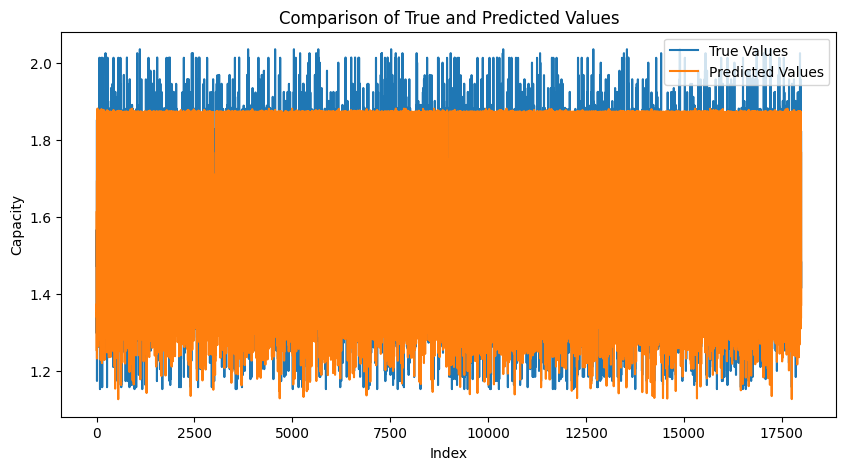

In [16]:
# testing the accuracy of model on test dataset
predicted_y = cap_model.predict(X_capacity_test)
true_y = y_capacity_test

mse = mean_squared_error(true_y, predicted_y)
mae = mean_absolute_error(true_y, predicted_y)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

plt.figure(figsize=(10, 5))

plt.plot(true_y, label='True Values')

plt.plot(predicted_y, label='Predicted Values')

plt.title('Comparison of True and Predicted Values')
plt.xlabel('Index')
plt.ylabel('Capacity')
plt.legend()
plt.show()

## predicting SOH (main method)

This is for predicting the SOH (currecnt capacity / initial capacity) which is used as input for the RUL model.

In [17]:
# spliting data into train, test, validation
X_SOH_train, X_SOH_testval, y_SOH_train, y_SOH_testval = train_test_split(
    X, y_SOH, test_size=0.2, random_state=42
)

X_SOH_test, X_SOH_validation, y_SOH_test, y_SOH_validation = train_test_split(
    X_SOH_testval, y_SOH_testval, test_size=0.5, random_state=42
)

In [18]:
# architecture of the model
time_steps = X_SOH_train.shape[1]
features = X_SOH_train.shape[2]

model = Sequential()

model.add(LSTM(100, return_sequences=True, input_shape=(time_steps, features)))
model.add(LSTM(100, return_sequences=True))
model.add(LSTM(100, return_sequences=False))
model.add(Dense(50, activation='relu'))
model.add(Dense(1, activation='linear'))

model.compile(optimizer='adam', loss='mean_squared_error')

In [19]:
# training the model
history = model.fit(X_SOH_train, y_SOH_train, epochs=20, validation_data=(X_SOH_validation, y_SOH_validation), verbose=1)
model.save('SOH_LSTM.h5')

Epoch 1/20
4500/4500 [==============================] - 59s 12ms/step - loss: 0.0091 - val_loss: 0.0070
Epoch 2/20
4500/4500 [==============================] - 57s 13ms/step - loss: 0.0054 - val_loss: 0.0046
Epoch 3/20
4500/4500 [==============================] - 58s 13ms/step - loss: 0.0051 - val_loss: 0.0058
Epoch 4/20
4500/4500 [==============================] - 58s 13ms/step - loss: 0.0049 - val_loss: 0.0053
Epoch 5/20
4500/4500 [==============================] - 57s 13ms/step - loss: 0.0047 - val_loss: 0.0039
Epoch 6/20
4500/4500 [==============================] - 57s 13ms/step - loss: 0.0039 - val_loss: 0.0035
Epoch 7/20
4500/4500 [==============================] - 58s 13ms/step - loss: 0.0036 - val_loss: 0.0032
Epoch 8/20
4500/4500 [==============================] - 57s 13ms/step - loss: 0.0034 - val_loss: 0.0034
Epoch 9/20
4500/4500 [==============================] - 58s 13ms/step - loss: 0.0032 - val_loss: 0.0030
Epoch 10/20
4500/4500 [==============================] - 58s 13m

c:\Users\hp\Desktop\Li-Ion-Battery-RUL-SOH-Prediction-main\venv\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


### Testing

In [20]:
# loading the model
SOH_model = load_model('SOH_LSTM.h5')
SOH_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 10, 100)           43200     
                                                                 
 lstm_7 (LSTM)               (None, 10, 100)           80400     
                                                                 
 lstm_8 (LSTM)               (None, 100)               80400     
                                                                 
 dense_4 (Dense)             (None, 50)                5050      
                                                                 
 dense_5 (Dense)             (None, 1)                 51        
                                                                 
Total params: 209101 (816.80 KB)
Trainable params: 209101 (816.80 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


563/563 [==============================] - 4s 5ms/step
Mean Squared Error: 0.0014863560654027699
Mean Absolute Error: 0.029881229433464614
Root Mean Squared Error: 0.038553288645753296


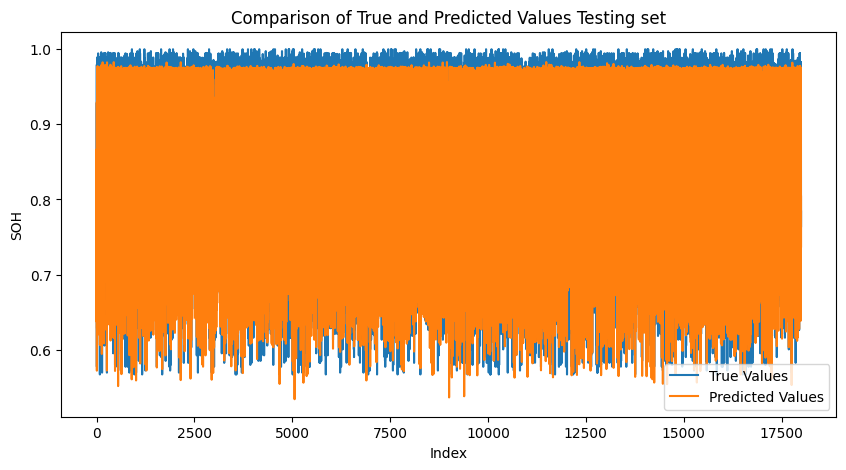

In [21]:
# testing the accuracy of model on thw test dataset
predicted_y = SOH_model.predict(X_SOH_test)
true_y = y_SOH_test

mse = mean_squared_error(true_y, predicted_y)
mae = mean_absolute_error(true_y, predicted_y)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

plt.figure(figsize=(10, 5))

plt.plot(true_y, label='True Values')

plt.plot(predicted_y, label='Predicted Values')

plt.title('Comparison of True and Predicted Values Testing set')
plt.xlabel('Index')
plt.ylabel('SOH')
plt.legend()
plt.show()

4500/4500 [==============================] - 20s 4ms/step
Mean Squared Error: 0.0015063497798382466
Mean Absolute Error: 0.03004468726184385
Root Mean Squared Error: 0.03881172219624178


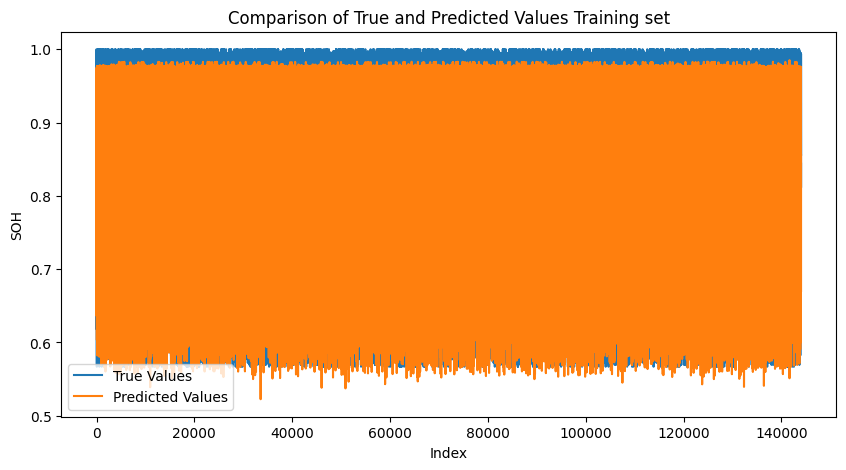

In [22]:
# testing the accuracy of model on train dataset
predicted_y = SOH_model.predict(X_SOH_train)
true_y = y_SOH_train

mse = mean_squared_error(true_y, predicted_y)
mae = mean_absolute_error(true_y, predicted_y)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

plt.figure(figsize=(10, 5))

plt.plot(true_y, label='True Values')

plt.plot(predicted_y, label='Predicted Values')

plt.title('Comparison of True and Predicted Values Training set')
plt.xlabel('Index')
plt.ylabel('SOH')
plt.legend()
plt.show()

# Predicting RUL

In [23]:
# reshaping the cyclic_RUL_x data so that each element is a numpy array
cyclic_RUL_x_reshaped = np.empty((cyclic_RUL_x.shape[0], 1))
for i in range(cyclic_RUL_x.shape[0]):
  cyclic_RUL_x_reshaped[i] = np.array([cyclic_RUL_x[i]])

In [24]:
# scaling the RUL values between 0 and 1
scaler = MinMaxScaler()
scaled_rul = scaler.fit_transform(cyclic_RUL_y.reshape(-1, 1))

In [25]:
# generating sequntial data for RUL prediction given SOH, here we use sequences of 3 cycles (not observation, note that the SOH and RUL are constant in each cycle)
def generate_sequences_RUL(capacity, RUL_GT, window_size):
  X, y_RUL = [], []
  for start in range(capacity.shape[0] - window_size + 1):
    end = start + window_size

    features = capacity[start:end]
    target_RUL = RUL_GT[end-1]
    X.append(features)
    y_RUL.append(target_RUL)

  return np.array(X), np.array(y_RUL)

In [26]:
X_for_RUL, y_RUL = generate_sequences_RUL(cyclic_RUL_x_reshaped, scaled_rul, 3)

In [27]:
# spliting the data into train, test, and validation
X_RUL_train, X_RUL_testval, y_RUL_train, y_RUL_testval = train_test_split(
    X_for_RUL, y_RUL, test_size=0.1, random_state=42
)

X_RUL_test, X_RUL_validation, y_RUL_test, y_RUL_validation = train_test_split(
    X_RUL_testval, y_RUL_testval, test_size=0.5, random_state=42
)

In [28]:
# architecture of the model
model = Sequential()
model.add(LSTM(units=200, return_sequences=True, input_shape=(X_RUL_train.shape[1],1)))
model.add(Dropout(0.3))
model.add(LSTM(units=200, return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(units=200))
model.add(Dropout(0.3))
model.add(Dense(units=50, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(units=1, activation='linear'))
model.compile(optimizer='adam',loss='mean_squared_error')

In [29]:
# training and saving the model
history = model.fit(X_RUL_train, y_RUL_train, epochs=200, validation_data=(X_RUL_validation, y_RUL_validation), verbose=1)
model.save('RUL_LSTM.h5')

Epoch 1/200
18/18 [==============================] - 5s 56ms/step - loss: 0.1347 - val_loss: 0.0997
Epoch 2/200
18/18 [==============================] - 0s 13ms/step - loss: 0.0731 - val_loss: 0.0465
Epoch 3/200
18/18 [==============================] - 0s 12ms/step - loss: 0.0641 - val_loss: 0.0442
Epoch 4/200
18/18 [==============================] - 0s 12ms/step - loss: 0.0574 - val_loss: 0.0386
Epoch 5/200
18/18 [==============================] - 0s 12ms/step - loss: 0.0499 - val_loss: 0.0180
Epoch 6/200
18/18 [==============================] - 0s 12ms/step - loss: 0.0351 - val_loss: 0.0106
Epoch 7/200
18/18 [==============================] - 0s 12ms/step - loss: 0.0286 - val_loss: 0.0155
Epoch 8/200
18/18 [==============================] - 0s 12ms/step - loss: 0.0245 - val_loss: 0.0061
Epoch 9/200
18/18 [==============================] - 0s 12ms/step - loss: 0.0229 - val_loss: 0.0069
Epoch 10/200
18/18 [==============================] - 0s 12ms/step - loss: 0.0234 - val_loss: 0.0095

c:\Users\hp\Desktop\Li-Ion-Battery-RUL-SOH-Prediction-main\venv\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


### testing

In [30]:
# loading the model
RUL_model = load_model('RUL_LSTM.h5')
RUL_model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_9 (LSTM)               (None, 3, 200)            161600    
                                                                 
 dropout (Dropout)           (None, 3, 200)            0         
                                                                 
 lstm_10 (LSTM)              (None, 3, 200)            320800    
                                                                 
 dropout_1 (Dropout)         (None, 3, 200)            0         
                                                                 
 lstm_11 (LSTM)              (None, 200)               320800    
                                                                 
 dropout_2 (Dropout)         (None, 200)               0         
                                                                 
 dense_6 (Dense)             (None, 50)               

1/1 [==============================] - 1s 878ms/step
Mean Squared Error: 0.010696947414627574
Mean Absolute Error: 0.07834127042609865
Root Mean Squared Error: 0.10342604804703491


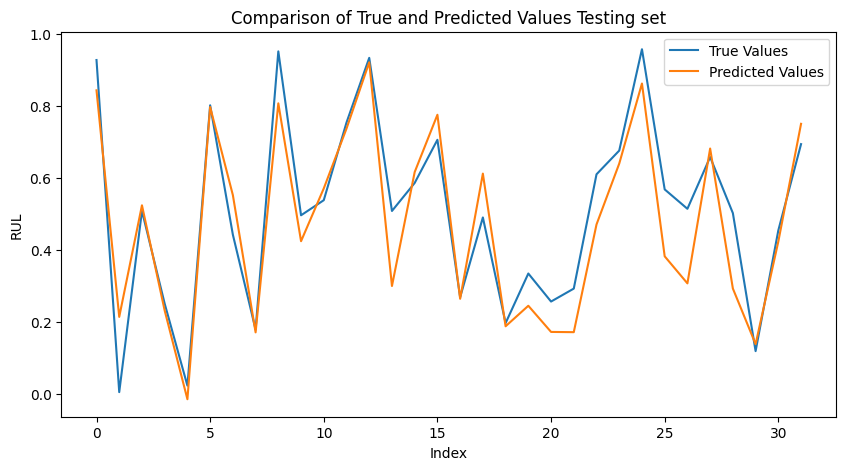

In [31]:
# testing the model on test dataset
predicted_y = RUL_model.predict(X_RUL_test)
true_y = y_RUL_test

mse = mean_squared_error(true_y, predicted_y)
mae = mean_absolute_error(true_y, predicted_y)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

plt.figure(figsize=(10, 5))

plt.plot(true_y, label='True Values')

plt.plot(predicted_y, label='Predicted Values')

plt.title('Comparison of True and Predicted Values Testing set')
plt.xlabel('Index')
plt.ylabel('RUL')
plt.legend()
plt.show()

18/18 [==============================] - 1s 4ms/step
Mean Squared Error: 0.007202254223950352
Mean Absolute Error: 0.06726137526456218
Root Mean Squared Error: 0.08486609584486818


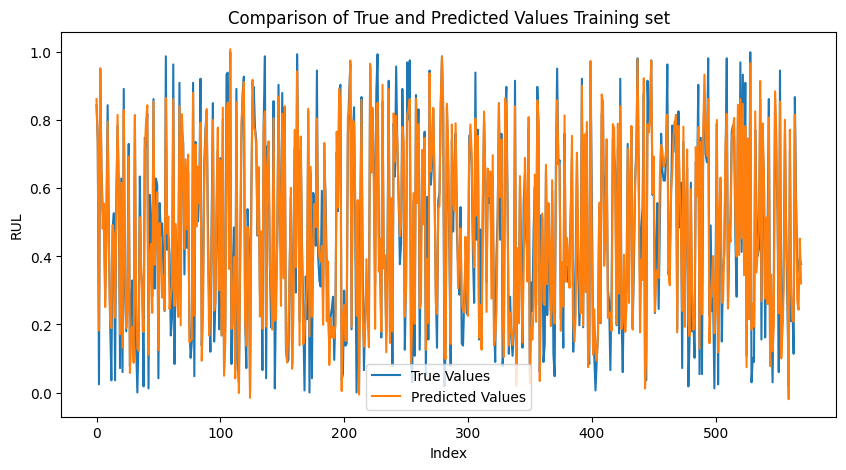

In [32]:
# testing the model on train dataset
predicted_y = RUL_model.predict(X_RUL_train)
true_y = y_RUL_train

mse = mean_squared_error(true_y, predicted_y)
mae = mean_absolute_error(true_y, predicted_y)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

plt.figure(figsize=(10, 5))

plt.plot(true_y, label='True Values')

plt.plot(predicted_y, label='Predicted Values')

plt.title('Comparison of True and Predicted Values Training set')
plt.xlabel('Index')
plt.ylabel('RUL')
plt.legend()
plt.show()